In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
from torchvision.models import VGG16_Weights

In [3]:
!pip install kagglehub

In [4]:
import kagglehub
import glob
# Download latest version
path = kagglehub.dataset_download("zaraks/pascal-voc-2007")

print("Path to dataset files:", path)
img_dir = path + "/VOCtrainval_06-Nov-2007/VOCdevkit/VOC2007/JPEGImages"


100%|██████████| 1.65G/1.65G [00:43<00:00, 40.8MB/s]

Extracting files...


Path to dataset files: /home/onyxia/.cache/kagglehub/datasets/zaraks/pascal-voc-2007/versions/1


In [5]:
img_dir

'/home/onyxia/.cache/kagglehub/datasets/zaraks/pascal-voc-2007/versions/1/VOCtrainval_06-Nov-2007/VOCdevkit/VOC2007/JPEGImages'

In [8]:
!ls '/home/onyxia/.cache/kagglehub/datasets/zaraks/pascal-voc-2007/versions/1/VOCtrainval_06-Nov-2007/VOCdevkit/VOC2007/'

Annotations  ImageSets	JPEGImages  SegmentationClass  SegmentationObject


In [3]:
import os 
lbl_dir=os.getcwd()+"/datasets/voc/labels"

In [4]:
images_link = sorted(glob.glob(img_dir + "/*.jpg"))
labels_link = sorted(glob.glob(lbl_dir + "/*.txt"))

In [5]:

from dataloader import DataGeneralLoader,DataSSD300
from dataloader import random_split
images_link = sorted(glob.glob(img_dir + "/*.jpg"))
labels_link = sorted(glob.glob(lbl_dir + "/*.txt"))

train_links,val_links,test_links=random_split(images_link, labels_link, test_size=0.15, val_size=0.15, seed=None)
trainloader = DataSSD300(
        **train_links, mode="train", gt_normalised=True
)
valloader = DataSSD300(
        **val_links, mode="test", gt_normalised=True
)

testloader = DataSSD300(
        **test_links, mode="test", gt_normalised=True
)

In [6]:

GeneralLoader = DataGeneralLoader(
        batch_size=26,
        multigpu=False,
)
train_dataloader, val_dataloader, test_dataloader = GeneralLoader(trainloader,valloader,testloader)
config={0: 'aeroplane',
 1: 'bicycle',
 2: 'bird',
 3: 'boat',
 4: 'bottle',
 5: 'bus',
 6: 'car',
 7: 'cat',
 8: 'chair',
 9: 'cow',
 10: 'diningtable',
 11: 'dog',
 12: 'horse',
 13: 'motorbike',
 14: 'person',
 15: 'pottedplant',
 16: 'sheep',
 17: 'sofa',
 18: 'train',
 19: 'tvmonitor'}

[10, 8]
BoundingBoxes([[ 13.9959, 123.3244, 268.9655, 268.5506],
               [271.3996,  83.6081, 300.0000, 132.0169]], format=BoundingBoxFormat.XYXY, canvas_size=(300, 300), clamping_mode=soft)


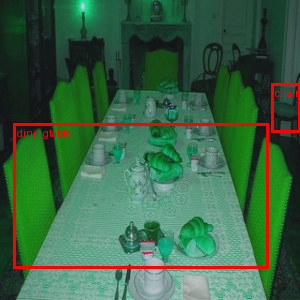

In [31]:
from torchvision.transforms.functional import pil_to_tensor
from torchvision.utils import draw_bounding_boxes
from torchvision.transforms.functional import to_pil_image
for image, labels_list, gt_box_list in train_dataloader:
    
    print([el-1 for el in labels_list[0].tolist()])
    print(gt_box_list[0])
    # unnormalize for visualization
    mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
    std = torch.tensor([0.229,0.224,0.225]).view(3,1,1)

    img_vis = image[0] * std + mean
    img_vis = (img_vis * 255).clamp(0,255).to(torch.uint8)

    drawn = draw_bounding_boxes(
        img_vis,
        boxes=gt_box_list[0],
        colors="red",
        labels=[config[el-1] for el in labels_list[0].tolist()],
        width=3
    )

    to_pil_image(drawn).show()
    break

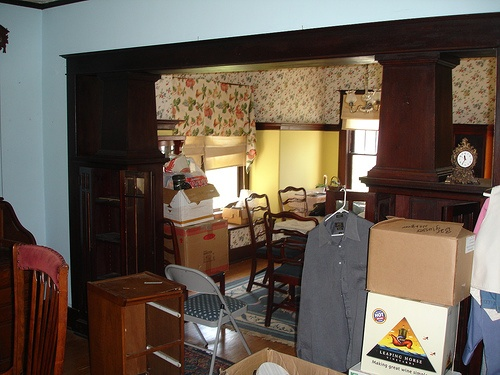

In [33]:
from PIL import Image
images=sorted(glob.glob(img_dir + "/*.jpg"))
img = Image.open(images[0]).convert("RGB")
img
